# Park evaluation scores by supervisor district

Rec & Park's [Annual Park Evaluation Scores](https://data.sfgov.org/Culture-and-Recreation/Annual-Park-Evaluation-Scores-FY15-now-/r33y-seqv/about_data)
(`r33y-seqv`): one maintenance score (0–1) per park per fiscal year, FY2015–FY2025.

Caveats to keep in mind:

- **No FY2021** — evaluations were suspended during COVID.
- **District assignments reflect current (post-2022) boundaries for all years.**
- Parks spanning multiple districts (e.g. Golden Gate Park) count toward each district listed.
- Observed scores only span **0.6–1.0**, so axes here don't start at zero — read differences accordingly.
- SF fiscal years run July–June: FY2025 = Jul 2024 – Jun 2025.

Supervisor tenures come from `data/reference/supervisors.csv`, hand-curated from the
Wikipedia membership timeline with corrections (Haney→Dorsey 2022, the D4
recall/appointments of 2025) verified against news reports.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sfdata import fetch

BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#898781", "#e1e0d9"

scores = fetch.load("park_scores")
scores["district"] = scores["supervisor_district"].astype(str).str.split(",")
scores = scores.explode("district")
scores["district"] = scores["district"].str.strip().astype(int)

by_dist = (
    scores.groupby(["fy", "district"])["park_score"].mean().rename("mean_score").reset_index()
)
scores.head()

,fy,park,park_type,park_score,psa,supervisor_district,district
0,2015,Park Presidio Blvd,Parkway,0.60,PSA1,"1, 2",1
0,2015,Park Presidio Blvd,Parkway,0.60,PSA1,"1, 2",2
1,2015,Gilman Playground,Neighborhood Park,0.61,PSA3,10,10
2,2015,Bayview K.C. Jones Playground,Neighborhood Park,0.62,PSA3,10,10
3,2017,Alice Chalmers Playground,Neighborhood Park,0.64,PSA3,11,11


## Each park's score, by district

Every dot is one park's annual score; FY2015 in gray, FY2025 in blue, with district
means as vertical ticks. Districts sorted by FY2025 mean.

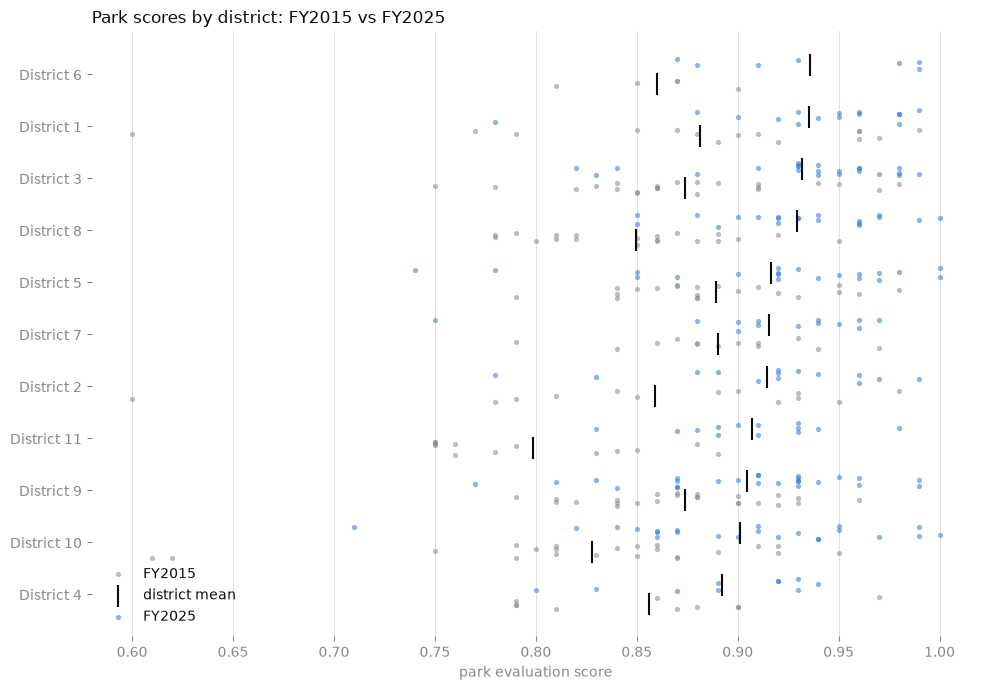

In [2]:
rng = np.random.default_rng(0)
order = (
    by_dist[by_dist.fy == 2025].sort_values("mean_score")["district"].tolist()
)
ypos = {d: i for i, d in enumerate(order)}

fig, ax = plt.subplots(figsize=(10, 7))
for fy, color, dy in [(2015, MUTED, -0.18), (2025, BLUE, 0.18)]:
    sub = scores[scores.fy == fy]
    y = sub["district"].map(ypos) + dy + rng.uniform(-0.13, 0.13, len(sub))
    ax.scatter(sub["park_score"], y, s=14, color=color, alpha=0.55, lw=0, label=f"FY{fy}")
    means = sub.groupby("district")["park_score"].mean()
    ax.scatter(means.values, [ypos[d] + dy for d in means.index], marker="|", s=230,
               color=INK, zorder=3, label="district mean" if fy == 2015 else None)

ax.set_yticks(range(len(order)), [f"District {d}" for d in order], color=INK)
ax.set_xlabel("park evaluation score", color=MUTED)
ax.tick_params(colors=MUTED)
ax.grid(axis="x", color=GRID, lw=0.7)
ax.set_axisbelow(True)
for s in ax.spines.values():
    s.set_visible(False)
ax.legend(frameon=False, loc="lower left", labelcolor=INK)
ax.set_title("Park scores by district: FY2015 vs FY2025", color=INK, loc="left")
fig.tight_layout()

## District means over time

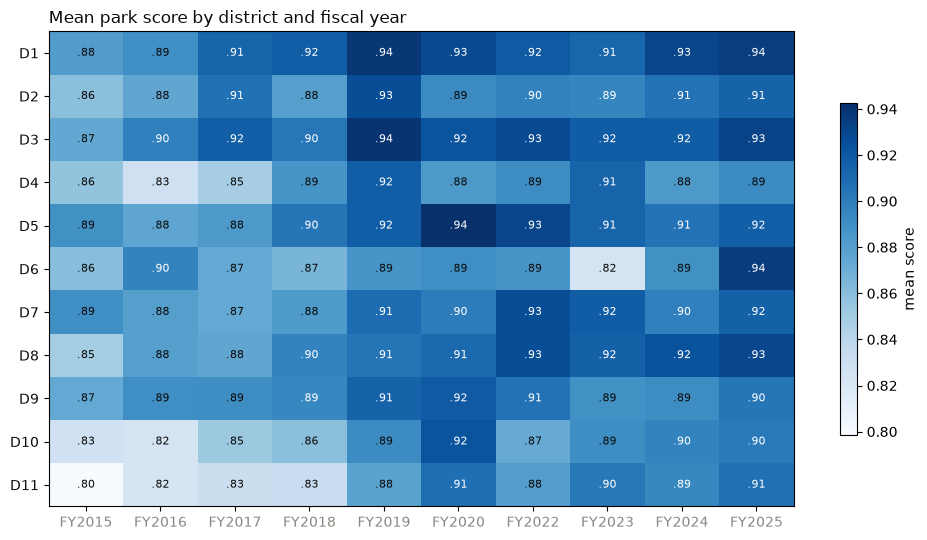

In [3]:
piv = by_dist.pivot(index="district", columns="fy", values="mean_score")

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(piv.values, cmap="Blues", aspect="auto",
               vmin=piv.values.min(), vmax=piv.values.max())
ax.set_xticks(range(len(piv.columns)), [f"FY{c}" for c in piv.columns], color=MUTED)
ax.set_yticks(range(len(piv.index)), [f"D{d}" for d in piv.index], color=INK)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        ax.text(j, i, f"{v:.2f}".lstrip("0"), ha="center", va="center", fontsize=8,
                color="white" if v > piv.values.mean() else INK)
ax.set_title("Mean park score by district and fiscal year", color=INK, loc="left")
fig.colorbar(im, ax=ax, shrink=0.7, label="mean score")
fig.tight_layout()

## On the map (FY2025)

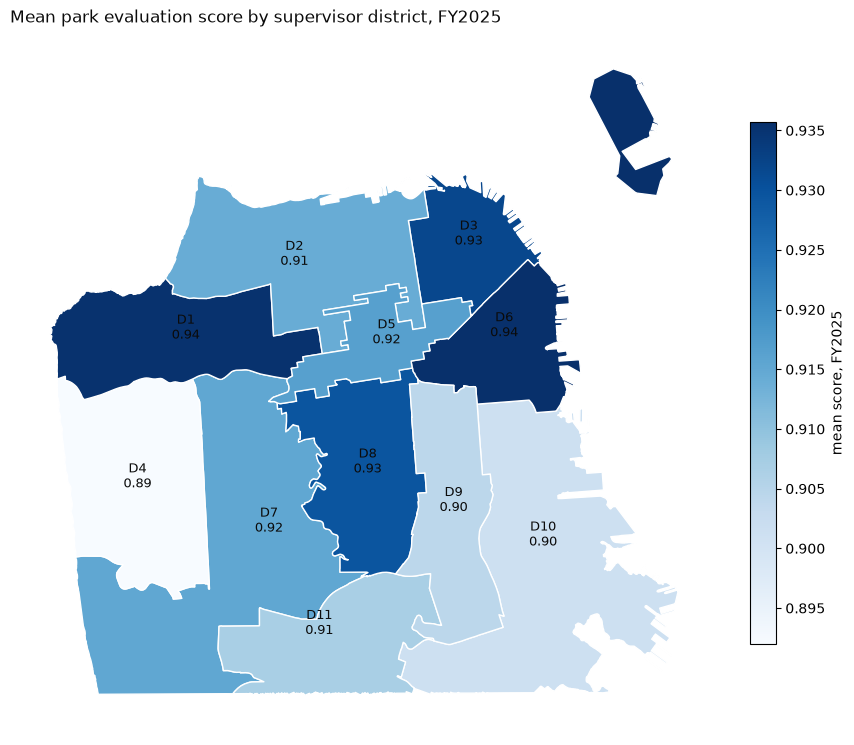

In [4]:
from shapely.geometry import box

districts_geo = fetch.load("supervisor_districts")
districts_geo["district"] = districts_geo["sup_dist"].astype(int)
geo25 = districts_geo.merge(by_dist[by_dist.fy == 2025], on="district")

VIEW = dict(xlim=(-122.525, -122.35), ylim=(37.70, 37.84))
view_box = box(VIEW["xlim"][0], VIEW["ylim"][0], VIEW["xlim"][1], VIEW["ylim"][1])

fig, ax = plt.subplots(figsize=(9, 9))
geo25.plot(ax=ax, column="mean_score", cmap="Blues", edgecolor="white", linewidth=1,
           legend=True, legend_kwds={"shrink": 0.6, "label": "mean score, FY2025"})
for _, r in geo25.iterrows():
    # Label within the visible area only — D4's polygon stretches out to the
    # Farallones, which would otherwise win "largest part".
    pt = r.geometry.intersection(view_box).representative_point()
    ax.annotate(f"D{r.district}\n{r.mean_score:.2f}", (pt.x, pt.y),
                ha="center", fontsize=9, color=INK)
ax.set(**VIEW)
ax.set_axis_off()
ax.set_title("Mean park evaluation score by supervisor district, FY2025", color=INK, loc="left")
fig.tight_layout()

## Scores under each supervisor

Mean of the district's annual means across the fiscal years each supervisor's tenure
overlaps (FY2015 onward). This is descriptive — park maintenance is Rec & Park's job,
not the supervisor's, so read this as *context*, not causation.

In [5]:
tenures = fetch.load_reference("supervisors")
tenures["start_date"] = pd.to_datetime(tenures["start_date"])
tenures["end_date"] = pd.to_datetime(tenures["end_date"]).fillna(pd.Timestamp.max)

def fys_served(row):
    fys = [fy for fy in sorted(by_dist.fy.unique())
           if row.start_date <= pd.Timestamp(fy, 6, 30)
           and row.end_date >= pd.Timestamp(fy - 1, 7, 1)]
    return fys

rows = []
for _, t in tenures.iterrows():
    fys = fys_served(t)
    if not fys:
        continue
    m = by_dist[(by_dist.district == t.district) & (by_dist.fy.isin(fys))]["mean_score"]
    rows.append({"district": t.district, "supervisor": t.supervisor,
                 "fiscal_years": f"FY{min(fys)}–FY{max(fys)}", "n_fys": len(fys),
                 "mean_of_district_means": round(m.mean(), 3)})

pd.DataFrame(rows).sort_values(["district", "fiscal_years"]).reset_index(drop=True)

,district,supervisor,fiscal_years,n_fys,mean_of_district_means
0,1,Eric Mar,FY2015–FY2017,3,0.895
1,1,Sandra Lee Fewer,FY2017–FY2020,4,0.924
2,1,Connie Chan,FY2022–FY2025,4,0.924
3,2,Mark Farrell,FY2015–FY2018,4,0.880
4,2,Catherine Stefani,FY2018–FY2025,7,0.901
5,2,Stephen Sherrill,FY2025–FY2025,1,0.914
6,3,David Chiu,FY2015–FY2015,1,0.874
7,3,Julie Christensen,FY2015–FY2016,2,0.886
8,3,Aaron Peskin,FY2016–FY2025,9,0.919
9,3,Danny Sauter,FY2025–FY2025,1,0.932


## Observations

- **Everything improved.** Citywide, district means rose from ~0.85 (FY2015) to ~0.91 (FY2025);
  every district's FY2025 mean beats its FY2015 mean.
- **Districts 10 and 11 started lowest** (0.83, 0.80 in FY2015) and closed most of the gap —
  the equity story is convergence, not divergence.
- **Districts 1 and 3 are persistently near the top** across the whole decade.
- **District 4 is the FY2025 laggard** (0.89) and has been below the citywide mean most years.
- **District 6 is volatile** — it has only ~7 parks, so a couple of low scores (as in FY2023)
  swing the mean; small-n districts deserve wide error bars mentally.

In [6]:
# Interactive: hover any district for its FY2025 mean and supervisor history context.
geo25[["district", "mean_score", "geometry"]].explore(
    column="mean_score", cmap="Blues", tiles="CartoDB positron",
    style_kwds={"weight": 1, "color": "white"},
)